In [1]:
from dotenv import load_dotenv
import os
load_dotenv()

True

In [2]:
OPENAI_API_KEY = os.getenv("TAVILY_API_KEY")

In [3]:
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY is missing in your .env")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [4]:
from langchain_openai import ChatOpenAI

In [7]:
chat_llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.7)

In [ ]:
chat_llm.invoke("Hello, how are you?").content

In [11]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [12]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

C:\Users\DIPIKA\AppData\Local\Temp\ipykernel_23388\1068719361.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)


In [13]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': "Indeed's 2026 US Jobs & Hiring Trends Report: How to Find Stability ...",
  'url': 'https://www.hiringlab.org/2025/11/20/indeed-2026-us-jobs-hiring-trends-report/',
  'content': 'new graduates isn’t that junior roles are being uniquely squeezed out, but that the entire job market is contracting, leaving fewer opportunities across the board. This dynamic is reflected in the contrast between a low overall unemployment rate (but a decline in job postings) and monthly payroll employment growth. For those already employed, things may feel steady enough. But for those trying to break in — especially outside of the handful of better-performing sectors like healthcare — the landscape looks barren. [...] In today’s “low-fire, low-hire” environment, those trying to enter the labor market in fields outside of healthcare (and a handful of other relatively high-demand fields, including civil engineering and construction) are bearing the heaviest burden. Young workers, in particular, are

In [14]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [15]:
search.invoke("what is the latest update on iphone17 release?")

Impersonate 'edge_101' does not exist, using 'random'


'Apple has unveiled four new iPhones: the iPhone 17, iPhone Air, iPhone 17 Pro and iPhone 17 Pro Max. Here\'s the lowdown on the specs, price, new features, design, dimensions and more. Release Date: Latest Prediction Unless one of the products (such as the iPad and iPad Air) has a release date on Wednesday, March 11, which is possible, I believe all the new stuff will go on sale ... Apple launched its new iPhone 17 lineup and ultra-thin iPhone Air in September 2025. The iPhone 17 is Apple\'s most affordable flagship iPhone, sold alongside the higher-end iPhone Air, iPhone 17 ... Discover the iPhone 17\'s groundbreaking features, including brighter displays, reverse wireless charging, and a sleek new design. Apple has unveiled the iPhone 17 during its "Awe Dropping" event, showcasing all the improvements, colors and more.'

In [23]:
search.invoke("Hello, how are you?")

'"Hello, How Are You" is a pop/rock song by the Australian rock band the Easybeats, released as a single in March 1968 and includ... Hello , How Are You ? is a campaign about connecting with those around us and engaging in open conversations about mental health. Hello people, how are you today? ... Hello everyone, how are you today? ... The law states you must have an education NOT where the education must ... hello how are you today sir? ... Hello , how are you today? ... The law states you must have an education NOT where the education must come from.... I miss you , dear friends, that\'s all maybe it\'s time to come back :D ... hello , how are you ... You must be logged in to comment. ... Gay, how are you'

In [24]:
from typing_extensions import TypedDict, Annotated
import operator

In [25]:
from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [26]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [27]:
{
    "messages": [HumanMessage(content="Hi, this is Deepika. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Deepika. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [45]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = search.invoke({"query": state["messages"][-1].content})  # AIMessage
    return {
        "messages": [response]
    }

In [56]:
def llm_call(state: GraphState) -> dict:
    query = state["messages"][-1].content
    response = search.invoke({"query": query})
    return {
        "messages": [AIMessage(content=response)]
    }

In [58]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [59]:
from langgraph.graph import StateGraph

In [60]:
builder = StateGraph(GraphState)

In [61]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [62]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [63]:
app = builder.compile()

In [64]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [65]:
from IPython.display import Image, display

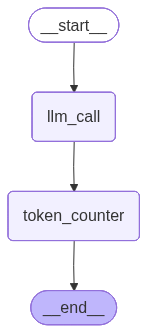

In [66]:
display(Image(app.get_graph().draw_mermaid_png()))

In [71]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Deepa. Say hello in detail.")]
})

In [73]:
result

{'messages': [HumanMessage(content='Hi, this is Deepa. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="2 May 2025 · Hi, I'm Deepika — a woman with a soft heart, strong mind, and a spark that believes in soulful connections. I'm not here for flings or fast fades. I value ... Hello, My name is Deepa, an East Coster that moved to the Bay Area. I've been learning ... YP_prichay Hello everyone thanks to giving me this chance for introducing myself in this group I am simply nature loving person and this is my prichay Name: Deepa Singh Age More results from www.facebook.com 1 Dec 2025 · Hello everyone, this is Deep Paraya, associate partner with Viral Pay. We ... Say yes to your entrepreneurship journey. See you at high tech Hyderabad ... 13 Dec 2025 · Each order is wrapped with the same attention to detail that ... Jan 5, 2026 · 293 views. 00:41. Why silver ? I have been asked this question a lot of times so ... 7 Nov 2025 · Everyone please put your h

In [74]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Deepa. Say hello in detail.
AIMessage : 2 May 2025 · Hi, I'm Deepika — a woman with a soft heart, strong mind, and a spark that believes in soulful connections. I'm not here for flings or fast fades. I value ... Hello, My name is Deepa, an East Coster that moved to the Bay Area. I've been learning ... YP_prichay Hello everyone thanks to giving me this chance for introducing myself in this group I am simply nature loving person and this is my prichay Name: Deepa Singh Age More results from www.facebook.com 1 Dec 2025 · Hello everyone, this is Deep Paraya, associate partner with Viral Pay. We ... Say yes to your entrepreneurship journey. See you at high tech Hyderabad ... 13 Dec 2025 · Each order is wrapped with the same attention to detail that ... Jan 5, 2026 · 293 views. 00:41. Why silver ? I have been asked this question a lot of times so ... 7 Nov 2025 · Everyone please put your hands together for the legacy award winner tonight Deepa Mehta. Hello everybod

In [16]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [17]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [19]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [20]:
wiki_tool.invoke("What is the latest update on iphone17 release?")

'No good Wikipedia Search Result was found'

In [21]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative artificial intelligence\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI to'

In [75]:
from langchain_community.tools import YouTubeSearchTool

In [76]:
tool=YouTubeSearchTool()

In [77]:
tool.name

'youtube_search'

In [78]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [79]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=fQw1_U22URk&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [80]:
def multiply(a:int,b:int) -> int:
    return a*b

In [81]:
multiply(10,20)

200

In [83]:
from langchain.tools import tool

In [84]:
@tool
def multiply(a:int,b:int) -> int:
    '''this tool is for the multiplication'''
    return a*b

In [85]:
multiply.invoke({"a":10,"b":20})

200

In [86]:
@tool
def get_word_length(word:str) -> int:
    """it is a tool to count the length of the word"""
    return len(word)

In [87]:
get_word_length.invoke("hello world")

11

In [88]:
import yfinance as yf

In [89]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"


In [90]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2573.70.'

In [91]:
[get_stock_price,get_word_length,multiply]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x000001B46AAE7880>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x000001B45A759300>),
 StructuredTool(name='multiply', description='this tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x000001B45A75BD80>)]

In [92]:
tools = [get_stock_price,get_word_length,multiply,wiki_tool]

In [93]:
search

DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text'))

In [ ]:
llm_with_tools=wiki_tool.bind_tools(tools)